#Data Ingestion

In [1]:
#Imported the required libraries to run
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#To read the source file
df=pd.read_csv('/content/HRDataset_v14.csv')

In [3]:
#To know how the data looks like
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,01-03-2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,02-01-2016,0,2


In [4]:
#To know how many rows and columns we have
df.shape

(311, 36)

In [5]:
#To know what all columns we have
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [6]:
#To know the data type of each column
df.dtypes

,0
Employee_Name,object
EmpID,int64
MarriedID,int64
MaritalStatusID,int64
GenderID,int64
EmpStatusID,int64
DeptID,int64
PerfScoreID,int64
FromDiversityJobFairID,int64
Salary,int64


In [7]:
#To check if any nulls present
df.isnull().sum()

,0
Employee_Name,0
EmpID,0
MarriedID,0
MaritalStatusID,0
GenderID,0
EmpStatusID,0
DeptID,0
PerfScoreID,0
FromDiversityJobFairID,0
Salary,0


In [8]:
#Replaced the null values with 0
df.fillna("0",inplace=True)

In [9]:
#To check if any duplicates present
df.duplicated().sum()

np.int64(0)

#Key Insights :-
- This dataset contains 311 rows and 36 columns.
- There are 207 null values in DateofTermination. Business team denied removing these null values, so we replaced by 0 (not terminated yet).
- There are no duplicated values.

#Data Preparation
- In "Employee_Name" column, the first and last name are seperated by comma, so that needs to be removed.
- There are date columns (DOB, DateofHire, DateofTermination, LastPerformanceReviewDate) that needs to be changed into date and time format.
- The column ManagerID needs to be converted into integer datatype as it is a whole number.

In [10]:
#To make deep copy so that the datas does not effect the original dataframe
df_copy=df.copy()

In [11]:
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,01-03-2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,02-01-2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,09-02-2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,02-01-2019,0,11


In [12]:
df_copy["Employee_Name"] = df_copy["Employee_Name"].str.replace(",","").str.strip()




In [13]:
df_copy['DOB'].unique()

array(['07-10-1983', '05-05-1975', '09/19/88', '09/27/88', '09-08-1989',
       '05/22/77', '05/24/79', '02/18/83', '02-11-1970', '01-07-1988',
       '01-12-1974', '02/21/74', '07-04-1988', '07/20/83', '07/15/77',
       '10/18/81', '04/17/66', '10/27/70', '04-04-1986', '04-06-1979',
       '12/22/70', '12/27/58', '09-01-1989', '09/21/90', '01/16/67',
       '07/30/64', '04-04-1987', '03-10-1970', '08/24/90', '11/24/87',
       '07/28/83', '10/30/69', '06-01-1964', '03-02-1980', '08/19/77',
       '11/22/66', '08-09-1983', '04-05-1987', '02-02-1983', '06-06-1986',
       '05/15/63', '01-02-1951', '02-09-1972', '02-12-1979', '08/24/83',
       '06-11-1970', '08/27/83', '05/31/88', '09-05-1985', '08/31/81',
       '11/25/78', '08/26/80', '09-08-1977', '08-12-1979', '12/17/75',
       '03/19/83', '03/31/77', '08/26/86', '04-10-1987', '09-09-1965',
       '04/19/90', '01/18/52', '11-05-1978', '09/14/79', '04/15/88',
       '10/31/77', '07-05-1979', '11-02-1975', '02/25/51', '04/19/67',
  

In [14]:
#Successfully converted the object columns into date and time format
cols = ["DOB", "DateofHire","DateofTermination", "LastPerformanceReview_Date"]

df_copy[cols] = df_copy[cols].apply(
    lambda col: pd.to_datetime(col, format="mixed", errors="coerce")
)


In [15]:
#Satistical Analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmpID,311.0,10156.000000,89.922189,10001.00,10078.50,10156.00,10233.5,10311.0
MarriedID,311.0,0.398714,0.490423,0.00,0.00,0.00,1.0,1.0
MaritalStatusID,311.0,0.810289,0.943239,0.00,0.00,1.00,1.0,4.0
GenderID,311.0,0.434084,0.496435,0.00,0.00,0.00,1.0,1.0
EmpStatusID,311.0,2.392283,1.794383,1.00,1.00,1.00,5.0,5.0
DeptID,311.0,4.610932,1.083487,1.00,5.00,5.00,5.0,6.0
PerfScoreID,311.0,2.977492,0.587072,1.00,3.00,3.00,3.0,4.0
FromDiversityJobFairID,311.0,0.093248,0.291248,0.00,0.00,0.00,0.0,1.0
Salary,311.0,69020.684887,25156.636930,45046.00,55501.50,62810.00,72036.0,250000.0
Termd,311.0,0.334405,0.472542,0.00,0.00,0.00,1.0,1.0


#Key Insights:-
- The highest salary is 250000 and lowest is 45046.

#Univariate Analysis

In [16]:
df.RecruitmentSource.value_counts()

,count
RecruitmentSource,
Indeed,87
LinkedIn,76
Google Search,49
Employee Referral,31
Diversity Job Fair,29
CareerBuilder,23
Website,13
Other,2
On-line Web application,1


*Insights: Most employees have been recruited from Indeed.*

In [17]:
df_copy['Employee_Name'].groupby(df_copy.EmpStatusID).count()

,Employee_Name
EmpStatusID,
1,184
2,11
3,14
4,14
5,88


In [18]:
df_copy["MarriedID"].value_counts()

,count
MarriedID,
0,187
1,124


*Insights:- 187 peopl

#Bivariate Analysis

In [19]:
#what is the avg enagement score for employees in each department?
df_copy.groupby('Department')['EngagementSurvey'].mean()

,EngagementSurvey
Department,
Admin Offices,4.393333
Executive Office,4.830000
IT/IS,4.154000
Production,4.129569
Sales,3.818710
Software Engineering,4.061818


*Insights:- Executive office has the highest engagement surveys.*

In [20]:
#Employees who are under PIP
df_copy[df_copy.PerformanceScore == "PIP"].Employee_Name.groupby(df_copy.Department).count()


,Employee_Name
Department,
IT/IS,1
Production,8
Sales,4


*Insights: These 13 employees are under PIP, from IT/IS, Production and Sales department.*

In [43]:
#why did they get pip?
df_copy[df_copy.PerformanceScore == "PIP"].groupby('Department')['EngagementSurvey'].mean()


,EngagementSurvey
Department,
IT/IS,1.20000
Production,2.45125
Sales,2.01000


*Insights:- Employees got PIP because there EngagementSurvey was very poor.

In [21]:
df_copy["ManagerName"].groupby(df_copy.Department).count()

,ManagerName
Department,
Admin Offices,9
Executive Office,1
IT/IS,50
Production,209
Sales,31
Software Engineering,11


*Insights:- Most Managers are from Production Department.*

#Multivariate Analysis

In [22]:
#What are the total absences and average engagement survey score for each department?
df_copy.groupby('Department').agg({'Absences': 'sum', 'EngagementSurvey': 'mean'})

,Absences,EngagementSurvey
Department,,
Admin Offices,78,4.393333
Executive Office,10,4.830000
IT/IS,522,4.154000
Production,2120,4.129569
Sales,358,3.818710
Software Engineering,96,4.061818


In [23]:
df_copy.groupby('Sex').agg({'Absences': 'mean', 'SpecialProjectsCount': 'sum'})

,Absences,SpecialProjectsCount
Sex,,
F,10.261364,183
M,10.207407,196


In [24]:
#What is maximum salary and minimum days late in the last 30 days for employees in each position?
df_copy.groupby('Position')[['Salary', 'DaysLateLast30']].agg(['max', 'min'])

Salary         DaysLateLast30    
                                 max     min            max min
Position                                                       
Accountant I                   64520   63000              0   0
Administrative Assistant       55000   49920              0   0
Area Sales Manager             74326   55875              6   0
BI Developer                   99020   90100              0   0
BI Director                   110929  110929              0   0
CIO                           220450  220450              0   0
Data Analyst                   93554   83552              0   0
Data Analyst                   88527   88527              0   0
Data Architect                150290  150290              0   0
Database Administrator        114800   97999              0   0
Director of Operations        170500  170500              0   0
Director of Sales             180000  180000              0   0
Enterprise Architect          103613  103613              0   0
IT Director                   178000  178000              0   0
IT Manager - DB               148999  140920              0   0
IT Manager - Infra            157000  157000              4   4
IT Manager - Support          138888  138888              0   0
IT Support                     74679   50178              0   0
Network Engineer               76029   50750              3   0
President & CEO               250000  250000              0   0
Principal Data Architect      120000  120000              0   0
Production Manager             88976   62957              3   0
Production Technician I        64991   45046              6   0
Production Technician II       74813   55315              6   0
Sales Manager                  72992   65729              2   0
Senior BI Developer            87921   81584              0   0
Shared Services Manager        93046   93046              0   0
Software Engineer             108987   83363              4   0
Software Engineering Manager   77692   77692              0   0
Sr. Accountant                106367   99351              0   0
Sr. DBA                       104437  100031              0   0
Sr. Network Engineer          107226   85028              0   0

In [39]:
top_bottom_10 = pd.concat([
    df_copy.sort_values(by="Salary", ascending=False).head(5),
    df_copy.sort_values(by="Salary", ascending=True).head(5)
])[["Employee_Name", "Salary", "PerformanceScore"]]

top_bottom_10


,Employee_Name,Salary,PerformanceScore
150,King Janet,250000,Fully Meets
308,Zamora Jennifer,220450,Exceeds
131,Houlihan Debra,180000,Fully Meets
96,Foss Jason,178000,Exceeds
55,Corleone Vito,170500,Exceeds
310,Zima Colleen,45046,Fully Meets
140,Jacobi Hannah,45069,Fully Meets
231,Rhoads Thomas,45115,Fully Meets
176,Mahoney Lauren,45395,Fully Meets
152,Kirill Alexandra,45433,Fully Meets


*Insights: Salary doesnot impact PerformanceScore of Employees.*

#Visualizations

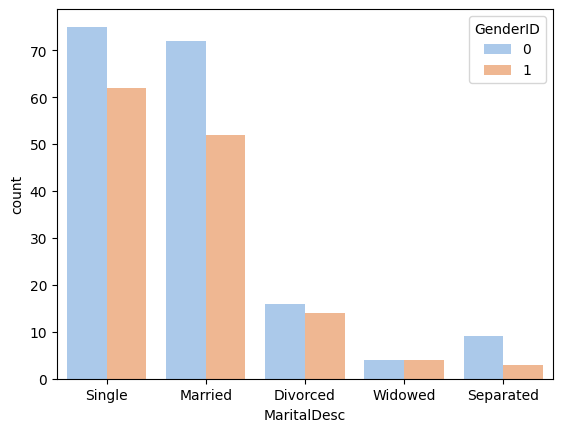

In [44]:
#marital status by gender
sns.countplot(x = 'MaritalDesc', hue = 'GenderID', data = df, palette = 'pastel')
plt.show()

*Insights: Mostly Males are single.*

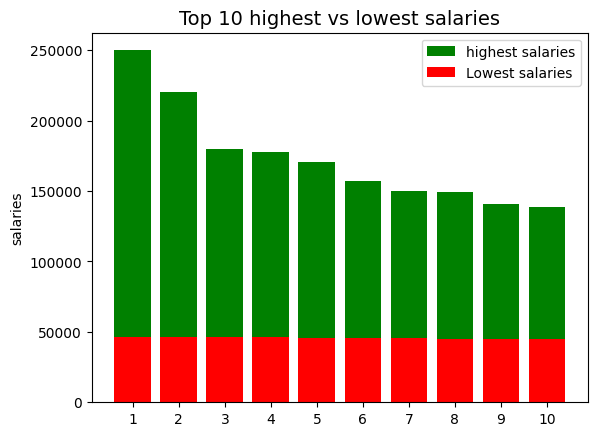

In [46]:
c = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y1 = df_copy.Salary.sort_values(ascending = False).head(10)
y2 = df_copy.Salary.sort_values(ascending = False).tail(10)

plt.bar(c, y1, color = 'g', label = 'highest salaries')
plt.bar(c, y2, color = 'r', label = 'Lowest salaries')


plt.title("Top 10 highest vs lowest salaries", fontsize = 14)

plt.xticks(c)
plt.ylabel('salaries')
plt.legend()
plt.show()

In [27]:
plot2=df_copy.PerformanceScore.value_counts()

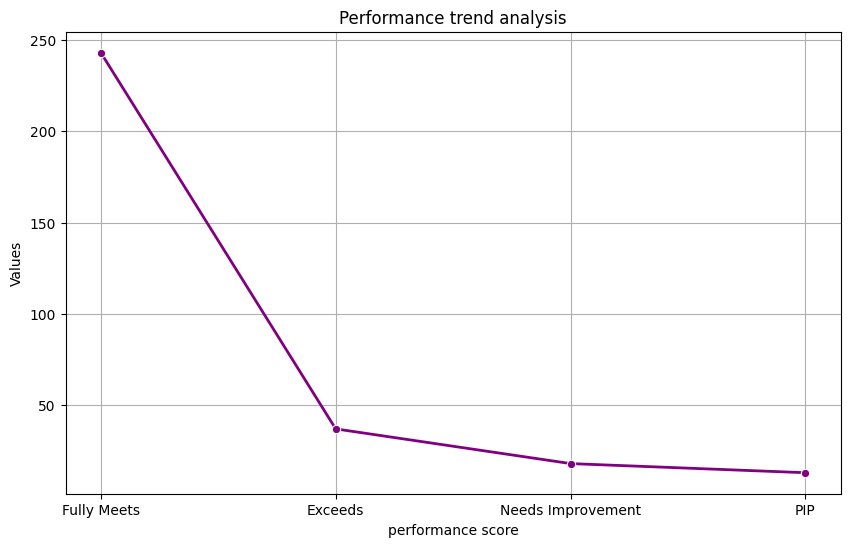

In [28]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = plot2, marker = 'o', color = 'purple', linewidth = 2)


plt.title("Performance trend analysis")
plt.xlabel("performance score")
plt.ylabel("Values")
plt.grid()
plt.show()

In [29]:
plot3=df_copy.EmpSatisfaction.value_counts()

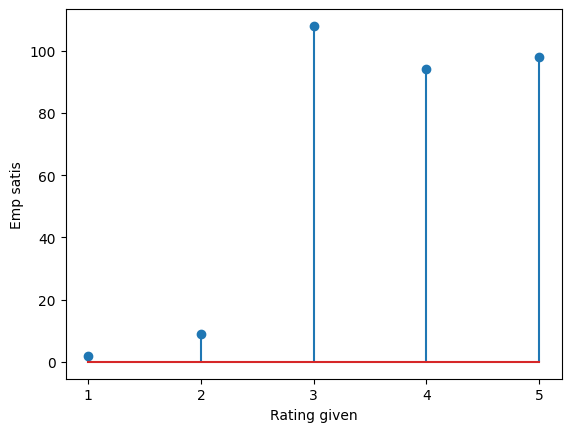

In [34]:
plt.stem(plot3.index, plot3)
plt.ylabel("No of emloyees")
plt.xticks(plot3.index)
plt.xlabel("Rating given")
plt.ylabel("Emp satis")
plt.show()

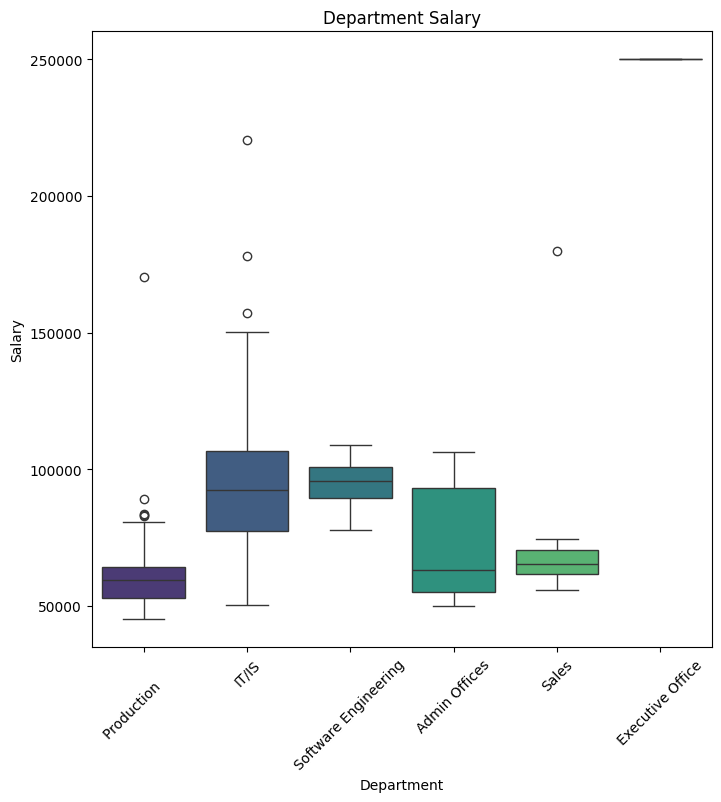

In [31]:
#Outliers in salary column with respect to each department

plt.figure(figsize = (8, 8))

sns.boxplot(x = 'Department', y = 'Salary', data = df, palette = 'viridis')
plt.title("Department Salary")

plt.xlabel("Department")
plt.ylabel("Salary")
plt.xticks(rotation = 45)
plt.show()

*Insights:- executives are paid the highest, while least salary in production.*

In [32]:
#How many employees have been terminated for each position
df_copy[df_copy['Termd'] == 1].groupby('Position')['Employee_Name'].count()

,Employee_Name
Position,
Administrative Assistant,2
Area Sales Manager,4
Data Analyst,1
Data Analyst,1
Database Administrator,3
Enterprise Architect,1
IT Manager - DB,1
Network Engineer,1
Principal Data Architect,1


*Insights:- Most terminations are from Production Technician 1 & 2 positions.*

In [33]:
#how many employees have been terminated for each reason?
df_copy[df_copy['Termd'] == 1].groupby('TermReason')['Employee_Name'].count()

,Employee_Name
TermReason,
Another position,20
Fatal attraction,1
Learned that he is a gangster,1
attendance,7
career change,9
gross misconduct,1
hours,8
maternity leave - did not return,3
medical issues,3


*Insights:- The main reason of termination was that employees got some other position and employees were unhappy.*